# Práctica 1. Sensado y Análisis de Video
### Ciencia de Datos para Sensores Inteligentes/Tópicos Selectos en Sistemas Interactivos
Estudiante: Leon-Altamirano F. Z. C.


## Dataset


ID:= identificador del estudiante capturado en el video.



// "D:\CICESE\Materias\C2\CDSI\Practicas\Practica 2 - Imagen\imagen"

## Importación de bibliotecas

In [48]:
import os
import re
from tqdm import tqdm

# Data
import random
import ast
import numpy as np
import cv2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mode
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
import tensorflow as tf

# Video
import pyrealsense2 as rs
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

## Extracción de Puntos Clave

In [2]:
dataset_path = './dataset'

In [3]:
dataset_df = pd.DataFrame(
    columns=[
        "file_name",
        "file_path",
        "student_id",
        "sample_number",
    ]
)

Cargamos los archivos de video y guardamos sus detalles en un DataFrame de pandas.

In [4]:
rows = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".bag"):
            file_path = os.path.join(root, file)
            match = re.match(r"([A-z]+)_([0-9]+)\.bag", file)
            if match:
                student_id = match.group(1)
                sample_number = match.group(2)
                
                rows.append(
                    {
                        "file_name": file,
                        "file_path": file_path,
                        "student_id": student_id,
                        "sample_number": sample_number,
                    }
                )

dataset_df = pd.concat([dataset_df, pd.DataFrame(rows)], ignore_index=True)

In [5]:
dataset_df.head()

,file_name,file_path,student_id,sample_number
0,DianaItzel_01.bag,./dataset\DianaItzel_01.bag,DianaItzel,01
1,DianaItzel_02.bag,./dataset\DianaItzel_02.bag,DianaItzel,02
2,DianaItzel_03.bag,./dataset\DianaItzel_03.bag,DianaItzel,03
3,DianaItzel_04.bag,./dataset\DianaItzel_04.bag,DianaItzel,04
4,DianaMinerva_01.bag,./dataset\DianaMinerva_01.bag,DianaMinerva,01


Seleccionamos un video al azar para inspeccionar sus metadatos.

In [6]:
video_aleatorio = random.choice(dataset_df['file_path'].tolist())
print(f"Inspeccionando archivo: {video_aleatorio}")

Inspeccionando archivo: ./dataset\Joan_02.bag


In [7]:
def obtener_metadata_bag(file_path):
    """
    Extrae algunos metadatos del video
    """
    metadata = {}
    
    pipeline = rs.pipeline()
    config = rs.config()

    rs.config.enable_device_from_file(config, file_path, repeat_playback=False)
    
    try:

        profile = pipeline.start(config)
        playback = profile.get_device().as_playback()
        
        duracion_us = playback.get_duration()
        duracion_seg = duracion_us
        metadata['Duración (seg)'] = duracion_seg
        
        streams_info = []
        for stream in profile.get_streams():
            vsp = stream.as_video_stream_profile()
            
            tipo = stream.stream_type().name
            ancho = vsp.width()
            alto = vsp.height()
            fps = vsp.fps()
            formato = stream.format().name
            
            streams_info.append(f"{tipo}: {ancho}x{alto} @ {fps}FPS ({formato})")
            
        metadata['Streams Configurados'] = " | ".join(streams_info)
        metadata['Nombre Archivo'] = file_path.split('/')[-1]
        
    except Exception as e:
        metadata['Error'] = str(e)
    finally:
        pipeline.stop()
        
    return metadata

In [8]:
meta_datos = obtener_metadata_bag(video_aleatorio)

df_meta = pd.DataFrame([meta_datos]).T
df_meta.columns = ["Valor"]
display(df_meta)

,Valor
Duración (seg),0 days 00:00:09.879688
Streams Configurados,depth: 1280x720 @ 30FPS (z16) | color: 1280x72...
Nombre Archivo,dataset\Joan_02.bag


Extraemos los joints que nos interesan.

In [9]:
# --- CONFIGURACIÓN ---
posing_model = "pose_landmarker_heavy.task"

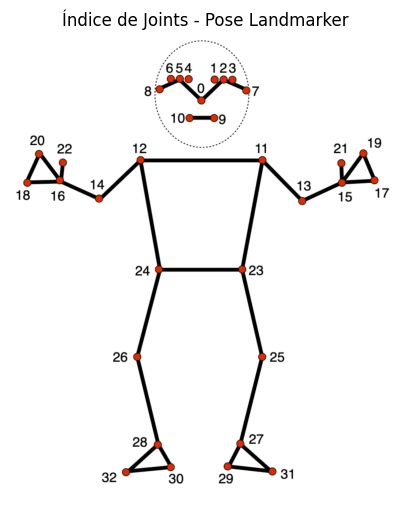

In [10]:
# Mostramos la imagen .png que tiene todos los joints para seleccionar los que nos interesan
display_png = cv2.imread('pose_landmarks_index.png')

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(display_png, cv2.COLOR_BGR2RGB))
plt.title("Índice de Joints - Pose Landmarker")
plt.axis('off')
plt.show()

Consideramos que los joints de interés son: 0, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,. Corresponden a la cabeza, hombros, codos, muñecas, caderas, rodillas y tobillos.

In [11]:
JOINTS = [0, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

In [12]:
def extract_gait_points(file_path, joint_ids=JOINTS):
    """
    Procesa un archivo .bag y extrae las coordenadas 3D de los centros articulares.
    # """
    
    # --- INICIALIZAR MODELO ---
    base_options = python.BaseOptions(model_asset_path='pose_landmarker_heavy.task')
    options = vision.PoseLandmarkerOptions(
        base_options=base_options, 
        running_mode=vision.RunningMode.VIDEO
    )

    with vision.PoseLandmarker.create_from_options(options) as detector:

        resultados = []
        bad_frames = [] 
        
        # CONFIGURAR REALSENSE
        pipeline = rs.pipeline()
        config = rs.config()
        rs.config.enable_device_from_file(config, file_path, repeat_playback=False)
        
        # Iniciar pipeline
        profile = pipeline.start(config)
        playback = profile.get_device().as_playback()
        playback.set_real_time(False)
        align = rs.align(rs.stream.color)

        color_profile = profile.get_stream(rs.stream.color).as_video_stream_profile()
        width = color_profile.width()
        height = color_profile.height()
        
        last_timestamp_ms = -1
        frame_number = 0
        try:
            while True:
                # Obtener frames
                frames = pipeline.wait_for_frames(timeout_ms=5000)
                aligned_frames = align.process(frames)
                depth_frame = aligned_frames.get_depth_frame()
                color_frame = aligned_frames.get_color_frame()
                
                if not depth_frame or not color_frame:
                    break

                # Metadata del frame
                current_timestamp_ms = int(playback.get_position() / 1e6)

                if current_timestamp_ms <= last_timestamp_ms:
                    current_timestamp_ms = last_timestamp_ms + 1
                last_timestamp_ms = current_timestamp_ms

                # MediaPipe Detection
                color_image = np.asanyarray(color_frame.get_data())
                mp_image = mp.Image(
                    image_format=mp.ImageFormat.SRGB, 
                    data=cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)
                )
                
                # Detección
                detection_result = detector.detect_for_video(mp_image, current_timestamp_ms)

                if detection_result.pose_landmarks:
                    pose = detection_result.pose_landmarks[0]

                    # Extraer coordenadas
                    for joint_id in joint_ids:
                        lm = pose[joint_id]
                        
                        px = int(np.clip(lm.x * width, 0, width - 1))
                        py = int(np.clip(lm.y * height, 0, height - 1))
                        pz = depth_frame.get_distance(px, py)
                        
                        resultados.append({
                            'frame_number': frame_number,
                            'timestamp_ms': current_timestamp_ms,
                            'joint_id': joint_id,
                            'x_px': px,
                            'y_px': py,
                            'z_m': pz,
                        })
                else:
                        bad_frames.append({
                            'frame_number': frame_number,
                            'timestamp_ms': current_timestamp_ms,
                        })
                frame_number += 1

        except RuntimeError:
            pass  # end of bag file (timeout or EOF)
        except Exception as e:
            print(f"Error procesando {file_path}: {e}")
        finally:
            pipeline.stop()
        
    return resultados, bad_frames

In [13]:
all_results = []
bad_frames_overall = []
for idx, row in tqdm(dataset_df.iterrows(), total=dataset_df.shape[0]):
    file_path = row['file_path']
    student_id = row['student_id']
    sample_number = row['sample_number']
    
    gait_points, bad_frames = extract_gait_points(file_path)
    bad_frames_overall.extend([{
        'student_id': student_id,
        'sample_number': sample_number,
        'bad_frames': bad_frames
    }])
    
    for point in gait_points:
        all_results.append({
            'student_id': student_id,
            'sample_number': sample_number,
            **point
        })
        
df_gait = pd.DataFrame(all_results)
df_bad_frames = pd.DataFrame(bad_frames_overall)

100%|██████████| 52/52 [16:45<00:00, 19.33s/it]


In [14]:
df_gait.to_csv("gait_points_long.csv", index=False)
df_bad_frames.to_csv("bad_frames_summary.csv", index=False)

## Normalización y eliminación de ruido

In [15]:
df_gait = pd.read_csv("gait_points_long.csv")
df_bad_frames = pd.read_csv("bad_frames_summary.csv")

Graficamos la distribución de los frames para identificar posibles patrones o problemas en la captura de datos.

In [16]:
# x_px, y_px, z_m are numeric
df_gait['x_px'] = pd.to_numeric(df_gait['x_px'], errors='coerce')
df_gait['y_px'] = pd.to_numeric(df_gait['y_px'], errors='coerce')
df_gait['z_m'] = pd.to_numeric(df_gait['z_m'], errors='coerce')

In [17]:
df_bad_frames['bad_frames_list'] = df_bad_frames['bad_frames'].apply(ast.literal_eval)

# Extraer todos los timestamps donde falló la detección
all_bad_timestamps = []
for row in df_bad_frames['bad_frames_list']:
    for frame in row:
        all_bad_timestamps.append(frame['timestamp_ms'])

good_frames = df_gait[['student_id', 'sample_number', 'timestamp_ms']].drop_duplicates()['timestamp_ms']

In [18]:
# contamos la cantidad de frames con posición = 0, en x y z, para cada joint
zero_counts_x = df_gait[df_gait['x_px'] == 0].groupby('joint_id').size()
zero_counts_y = df_gait[df_gait['y_px'] == 0].groupby('joint_id').size()
zero_counts_z = df_gait[df_gait['z_m'] == 0].groupby('joint_id').size()

zero_counts_x = zero_counts_x.reindex(JOINTS, fill_value=0)
zero_counts_y = zero_counts_y.reindex(JOINTS, fill_value=0)
zero_counts_z = zero_counts_z.reindex(JOINTS, fill_value=0)

zero_counts_summary = pd.DataFrame({
    'joint_id': JOINTS,
    'zero_x_count': zero_counts_x.values,
    'zero_y_count': zero_counts_y.values,
    'zero_z_count': zero_counts_z.values
})

zero_counts_summary

,joint_id,zero_x_count,zero_y_count,zero_z_count
0,0,13,0,75
1,11,1,0,180
2,12,30,0,104
3,13,7,0,400
4,14,30,0,298
5,15,8,0,857
6,16,29,0,836
7,23,9,0,740
8,24,29,0,768
9,25,11,0,1475


Como se observa, la mayoría de los frames tienen dificultad en la detección de puntos en la coordenada z, principalmente los puntos debajo de la cintura.

In [19]:
zero_joints_ts = df_gait[df_gait['z_m'] == 0]['timestamp_ms']

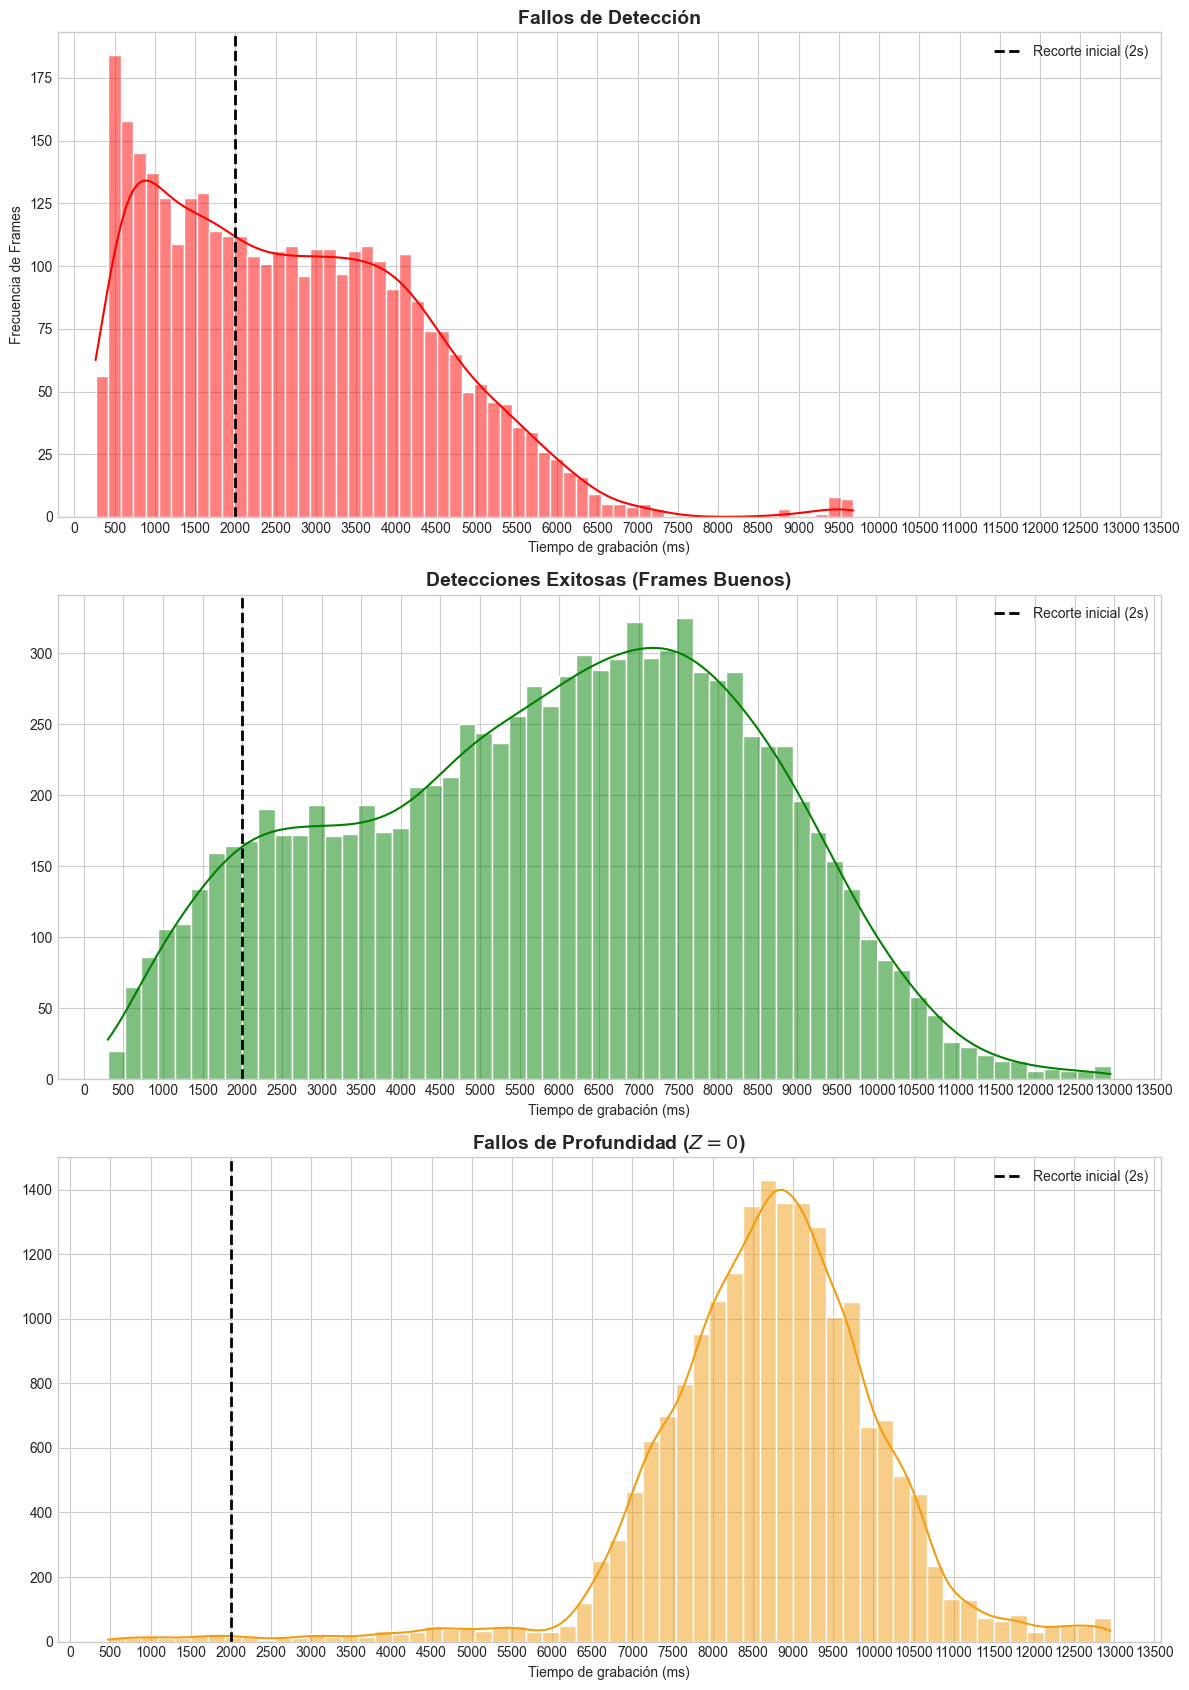

In [20]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(3, 1, figsize=(12, 17))

max_ts = max(max(all_bad_timestamps), max(good_frames), max(zero_joints_ts))
ticks_x = np.arange(0, max_ts + 1000, 500)

cut_off = 2000

# Histograma de frames con detección fallida
sns.histplot(all_bad_timestamps, bins=60, kde=True, color='red', edgecolor='white', alpha=0.5, ax=axes[0])
axes[0].axvline(cut_off, color='black', linestyle='--', linewidth=2, label='Recorte inicial (2s)')
axes[0].set_title('Fallos de Detección', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tiempo de grabación (ms)')
axes[0].set_ylabel('Frecuencia de Frames')
axes[0].set_xticks(ticks_x)
axes[0].legend(

)

# Histograma de frames con detección exitosa
sns.histplot(good_frames, bins=60, kde=True, color='green', edgecolor='white', alpha=0.5, ax=axes[1])
axes[1].axvline(cut_off, color='black', linestyle='--', linewidth=2, label='Recorte inicial (2s)')
axes[1].set_title('Detecciones Exitosas (Frames Buenos)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tiempo de grabación (ms)')
axes[1].set_ylabel('')
axes[1].set_xticks(ticks_x)
axes[1].legend()

# Histograma de frames con coordenada z = 0 (fallos de profundidad)
sns.histplot(zero_joints_ts, bins=60, kde=True, color='#f39c12', edgecolor='white', alpha=0.5, ax=axes[2])
axes[2].axvline(cut_off, color='black', linestyle='--', linewidth=2, label='Recorte inicial (2s)')
axes[2].set_title('Fallos de Profundidad ($Z=0$)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Tiempo de grabación (ms)')
axes[2].set_ylabel('')
axes[2].set_xticks(ticks_x)
axes[2].legend()

plt.tight_layout()
plt.show()

De los histogramas anteriores, se puede observar que el tiempo en el cual ocurren la mayoría de fallos de detección es principalmente al inicio. Por tal motivo, se decidió eliminar los frames con timestamp menor a 2000 ms.

Se realizará un recorte adaptativo, si a partir de cierto timestamp empiezan a aparecer fallos de detección, se eliminarán los frames posteriores a dicho timestamp.

In [21]:
def dynamic_cut_gait(df, start_ms=2000, quality_threshold=0.8):
    cleaned_chunks = []

    for (sid, sn), group in df.groupby(["student_id", "sample_number"]):
        # Recorte inicial
        video = group[group["timestamp_ms"] >= start_ms].copy()
        if video.empty:
            continue

        # Calidad por frame y encontrar el último punto estable
        frame_quality = video.groupby("timestamp_ms")["z_m"].apply(
            lambda x: (x > 0).mean()
        )
        valid_ts = frame_quality[frame_quality >= quality_threshold].index

        if len(valid_ts) == 0:
            continue

        # Recorte dinámico al último timestamp bueno
        video = video[video["timestamp_ms"] <= valid_ts.max()].copy()

        # Tratamos los valores de z_m <= 0 como fallos de detección y los marcamos como NaN para interpolar
        video.loc[video["z_m"] <= 0, "z_m"] = np.nan

        columns_to_interpolate = ["x_px", "y_px", "z_m"]

        for jid, jgroup in video.groupby("joint_id"):
            sorted_g = jgroup.sort_values("timestamp_ms")
            for c in columns_to_interpolate:
                video.loc[sorted_g.index, c] = (
                    sorted_g[c].interpolate(method="linear").bfill().ffill()
                )

        cleaned_chunks.append(video)

    return pd.concat(cleaned_chunks, ignore_index=True)

In [22]:
df_gait_cleaned = dynamic_cut_gait(df_gait, start_ms=2000, quality_threshold=0.8)

In [23]:
df_gait_cleaned.to_csv("gait_points_cleaned.csv", index=False)

## Extracción de características

In [24]:
df_gait_cleaned = pd.read_csv("gait_points_cleaned.csv")

Pasamos del formato long a un formato wide, donde cada fila corresponde a un frame y cada columna corresponde a una coordenada de un joint específico. Esto facilitará la extracción de características y el análisis posterior.

In [25]:
df_wide = df_gait_cleaned.pivot_table(
    index=['student_id', 'sample_number', 'timestamp_ms'],
    columns='joint_id',
    values=['x_px', 'y_px', 'z_m']
)

In [26]:
df_wide.columns = [f"{col}_{int(joint)}" for col, joint in df_wide.columns]
df_wide = df_wide.reset_index()

In [27]:
df_wide.head()

,student_id,sample_number,timestamp_ms,x_px_0,x_px_11,x_px_12,x_px_13,x_px_14,x_px_15,x_px_16,...,z_m_23,z_m_24,z_m_25,z_m_26,z_m_27,z_m_28,z_m_29,z_m_30,z_m_31,z_m_32
0,DianaItzel,1,2009,557.0,569.0,548.0,574.0,542.0,575.0,542.0,...,10.312000,9.618000,9.482000,9.904000,10.003000,10.873000,10.155001,10.873000,10.260000,10.420
1,DianaItzel,1,2038,558.0,571.0,549.0,575.0,542.0,576.0,543.0,...,9.953000,9.482000,9.712001,10.155001,10.003000,10.698001,10.104000,10.642000,10.207001,10.260
2,DianaItzel,1,2072,559.0,572.0,550.0,575.0,543.0,577.0,543.0,...,10.207001,9.437000,9.712001,10.155001,10.053000,10.585000,10.053000,10.698001,10.104000,10.260
3,DianaItzel,1,2105,559.0,573.0,550.0,576.0,544.0,578.0,544.0,...,9.953000,9.393001,9.904000,9.759001,10.155001,10.474001,10.155001,10.530001,10.104000,10.585
4,DianaItzel,1,2144,560.0,573.0,550.0,577.0,545.0,578.0,544.0,...,9.618000,9.219001,9.807000,9.482000,10.155001,10.207001,10.155001,10.104000,10.155001,10.642


La siguiente función convierte las coordenadas de píxeles a metros utilizando la profundidad para normalizar las medidas.

In [28]:
def convert_to_meters(df, joints, fx=640, fy=640, cx=640, cy=360):
    """
    Convierte x_px y y_px a coordenadas x_m y y_m usando la profundidad z_m.
    """
    for j in joints:
        # X_m = (x_px - cx) * z_m / fx
        df[f'x_m_{j}'] = (df[f'x_px_{j}'] - cx) * df[f'z_m_{j}'] / fx
        # Y_m = (y_px - cy) * z_m / fy
        df[f'y_m_{j}'] = (df[f'y_px_{j}'] - cy) * df[f'z_m_{j}'] / fy
    return df

La siguiente función es utilizada para extraer los ángulos articulares a partir de las coordenadas de los joints. Se calcula el ángulo entre tres puntos específicos para cada articulación de interés.

In [29]:
def extract_angles(df, p_a, p_b, p_c):
    """
    Extrae el ángulo entre tres puntos (p_a, p_b, p_c) para cada frame.
    """
    v_ba = np.array(
        [df[f"x_px_{p_a}"], df[f"y_px_{p_a}"], df[f"z_m_{p_a}"]]
    ) - np.array([df[f"x_px_{p_b}"], df[f"y_px_{p_b}"], df[f"z_m_{p_b}"]])

    v_bc = np.array(
        [df[f"x_px_{p_c}"], df[f"y_px_{p_c}"], df[f"z_m_{p_c}"]]
    ) - np.array([df[f"x_px_{p_b}"], df[f"y_px_{p_b}"], df[f"z_m_{p_b}"]])

    dot_product = np.einsum('ij,ij->j', v_ba, v_bc)
    norm_ba = np.linalg.norm(v_ba, axis=0)
    norm_bc = np.linalg.norm(v_bc, axis=0)

    denom = norm_ba * norm_bc
    mask = denom > 0
    cosine_angle = np.full_like(denom, np.nan)
    np.divide(dot_product, denom, out=cosine_angle, where=mask)

    return np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

La siguiente función extrae las características de interés: ángulos articulares, métricas espacio-temporales y proporciones físicas.

In [30]:
def extraer_features(df_wide):
    df = df_wide.copy()
    
    # --- ÁNGULOS ARTICULARES ---
    # Rodillas
    df['ang_rodilla_izq'] = extract_angles(df, 23, 25, 27)
    df['ang_rodilla_der'] = extract_angles(df, 24, 26, 28)
    # Caderas
    df['ang_cadera_izq'] = extract_angles(df, 11, 23, 25)
    df['ang_cadera_der'] = extract_angles(df, 12, 24, 26)
    # Tobillos (Punta del pie)
    df['ang_tobillo_izq'] = extract_angles(df, 25, 27, 31)
    df['ang_tobillo_der'] = extract_angles(df, 26, 28, 32)
    
    # --- Métricas de los pasos ---
    # Longitud de paso (distancia entre pies en eje Z)
    df['longitud_paso'] = np.abs(df['z_m_29'] - df['z_m_30'])
    # Ancho de paso (distancia entre pies en eje X)
    df['ancho_paso'] = np.abs(df['x_m_29'] - df['x_m_30'])
    
    # --- Centro de Masa ---
    # Mediante la cadera
    df['com_y'] = (df['y_m_23'] + df['y_m_24']) / 2
    df['com_x'] = (df['x_m_23'] + df['x_m_24']) / 2
    
    # --- Proporción ---
    dist_hombros = np.sqrt((df['x_m_11']-df['x_m_12'])**2 + (df['y_m_11']-df['y_m_12'])**2)
    dist_caderas = np.sqrt((df['x_m_23']-df['x_m_24'])**2 + (df['y_m_23']-df['y_m_24'])**2)
    df['proporcion_hombro_cadera'] = dist_hombros / dist_caderas
    
    return df

In [31]:
def gen_features_vector(df_features, feature_columns):
    """
    Genera un vector de características para cada muestra (student_id + sample_number).
    """
    feature_vectors = []
    
    for (sid, sn), group in df_features.groupby(['student_id', 'sample_number']):
        vector = group[feature_columns].mean().values
        feature_vectors.append({
            'student_id': sid,
            'sample_number': sn,
            **{col: vector[i] for i, col in enumerate(feature_columns)}
        })
    
    return pd.DataFrame(feature_vectors)

In [32]:
df_wide_m = convert_to_meters(df_wide, JOINTS)

In [33]:
df_wide_m.to_csv("gait_points_wide_meters.csv", index=False)

In [34]:
df_signals = extraer_features(df_wide_m)
df_signals.head()

,student_id,sample_number,timestamp_ms,x_px_0,x_px_11,x_px_12,x_px_13,x_px_14,x_px_15,x_px_16,...,ang_rodilla_der,ang_cadera_izq,ang_cadera_der,ang_tobillo_izq,ang_tobillo_der,longitud_paso,ancho_paso,com_y,com_x,proporcion_hombro_cadera
0,DianaItzel,1,2009,557.0,569.0,548.0,574.0,542.0,575.0,542.0,...,177.938613,170.325186,171.113137,178.941989,162.850394,0.717999,0.318622,-1.549517,-1.257942,2.174048
1,DianaItzel,1,2038,558.0,571.0,549.0,575.0,542.0,576.0,543.0,...,174.753392,168.910765,174.970906,176.706222,166.001006,0.538000,0.309947,-1.503176,-1.219888,1.903452
2,DianaItzel,1,2072,559.0,572.0,550.0,575.0,543.0,577.0,543.0,...,176.967894,167.164019,172.695834,176.810313,166.509353,0.645000,0.323297,-1.519341,-1.224141,1.991461
3,DianaItzel,1,2105,559.0,573.0,550.0,576.0,544.0,578.0,544.0,...,173.890030,167.401454,175.376218,174.264840,166.739385,0.375000,0.256078,-1.488516,-1.198724,1.952018
4,DianaItzel,1,2144,560.0,573.0,550.0,577.0,545.0,578.0,544.0,...,178.008287,171.500468,171.167385,174.293567,161.584314,0.051001,0.183712,-1.449410,-1.153212,2.247651


In [35]:
df_signals.to_csv("gait_signals.csv", index=False)

## Construcción y Evaluación de Modelos

Como se utilizarán modelos de Deep Learning, se crearán ventanas de tiempo.

In [36]:
features = [
    "ang_rodilla_izq",
    "ang_rodilla_der",
    "ang_cadera_izq",
    "ang_cadera_der",
    "ang_tobillo_izq",
    "ang_tobillo_der",
    "longitud_paso",
    "ancho_paso",
    "com_y",
    "com_x",
    "proporcion_hombro_cadera"
]

In [37]:
def create_time_windows(df, window_size=60, step_size=30, features_columns=None):
    """
    Crea ventanas de tiempo para cada muestra.
    """
    X, y, video_keys = [], [], []

    for (sid, sn), group in df.groupby(['student_id', 'sample_number']):
        data = group[features_columns].values

        for start in range(0, len(data) - window_size + 1, step_size):
            ventana = data[start:start + window_size]
            X.append(ventana)
            y.append(sid)

            # añadimos la etiqueta del video
            video_keys.append(f"{sid}_{sn}")

    return np.array(X), np.array(y), np.array(video_keys)

In [38]:
X_raw, y_raw, video_ids_raw = create_time_windows(df_signals, window_size=30, step_size=15, features_columns=features)

In [39]:
# get unique video keys and print
unique_video_keys = np.unique(video_ids_raw)
print(f"Videos únicos encontrados: {len(unique_video_keys)}")

Videos únicos encontrados: 50


Normalizamos los ángulos, pues tienen valores muy distintos a las métricas espacio-temporales y proporciones físicas. Esto es importante para que el modelo de Deep Learning pueda aprender de manera efectiva.

In [40]:
# Normalizar características (X)
N, T, F = X_raw.shape
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_raw.reshape(-1, F)).reshape(N, T, F)

# Convertir etiquetas (y)
encoder = LabelEncoder()
y_int = encoder.fit_transform(y_raw)
n_classes = len(np.unique(y_int))
y_onehot = to_categorical(y_int)

In [41]:
# X_train, X_test, y_train, y_test = train_test_split(X_norm, y_onehot, test_size=0.5, stratify=y_int, random_state=42)

## Construcción y Evaluación de Modelos

### Definición de Modelos

Se utilizarán los modelos: LSTM, CNN1D.

In [42]:
def build_lstm(input_shape, n_classes):
    model = Sequential(
        [
            # Capa de entrada LSTM
            Input(shape=input_shape),
            LSTM(64, return_sequences=True),
            BatchNormalization(),
            Dropout(0.3),
            # Segunda capa LSTM para capturar patrones más complejos
            LSTM(32, return_sequences=False),
            Dropout(0.3),
            # Capas Densas de clasificación
            Dense(64, activation="relu"),
            BatchNormalization(),
            Dense(n_classes, activation="softmax"),
        ]
    )

    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


def build_cnn1d(input_shape, n_classes):
    model = Sequential(
        [
            Input(shape=input_shape),
            # Primera capa convolucional: busca patrones de movimiento cortos
            Conv1D(filters=64, kernel_size=3, activation="relu"),
            BatchNormalization(),
            MaxPooling1D(pool_size=2),
            # Segunda capa convolucional: patrones más complejos
            Conv1D(filters=128, kernel_size=3, activation="relu"),
            BatchNormalization(),
            MaxPooling1D(pool_size=2),
            Flatten(),  # Convertimos el mapa de características en un vector
            Dense(64, activation="relu"),
            Dropout(0.5),
            Dense(n_classes, activation="softmax"),
        ]
    )

    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


def build_cnn_lstm(input_shape, n_classes):
    model = Sequential(
        [
            Input(shape=input_shape),
            # Extraemos patrones locales con Convolución
            Conv1D(64, kernel_size=3, activation="relu", padding="same"),
            BatchNormalization(),
            # Pasamos a la LSTM para analizar la secuencia temporal
            LSTM(64, return_sequences=False),
            Dropout(0.4),
            Dense(64, activation="relu"),
            Dense(n_classes, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model

### Entrenamiento

In [ ]:
def evaluar_por_video(y_true_windows, y_pred_windows, video_ids_test, encoder):
    video_results = []
    unique_videos = np.unique(video_ids_test)
    
    for vid in unique_videos:
        # Encontrar qué ventanas pertenecen a este video específico
        indices = np.where(video_ids_test == vid)[0]
        
        # Obtener las predicciones y la etiqueta real para esas ventanas
        preds_video = y_pred_windows[indices]
        real_label = y_true_windows[indices[0]]
        
        # Votación Mayoritaria
        voto_ganador = mode(preds_video, keepdims=True).mode[0]
        
        # Guardar resultado
        video_results.append({
            'video': vid,
            'real': encoder.inverse_transform([real_label])[0],
            'pred': encoder.inverse_transform([voto_ganador])[0],
            'correcto': real_label == voto_ganador
        })
    
    return pd.DataFrame(video_results)

In [51]:
def set_global_seed(seed=42):
    """Congela todas las fuentes de aleatoriedad"""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [ ]:
def evaluate_with_kfold(model_builder, X, y_int, y_onehot, encoder, video_ids, n_classes, name, n_splits=4):
    # Establecer semilla global para reproducibilidad
    set_global_seed(42)
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    groups = video_ids

    # Para guardar predicciones
    oof_preds = np.zeros((X.shape[0], n_classes))
    fold_accuracies = []
    all_video_results = []



    print(f"\n{'='*40}")
    print(f" EVALUANDO {name} CON STRATIFIED GROUP K-FOLD")
    print(f"{'='*40}")
    
    for i, (train_idx, val_idx) in enumerate(sgkf.split(X, y_int, groups=groups)):
        # Re-construir modelo para limpiar pesos
        model = model_builder((X.shape[1], X.shape[2]), n_classes)
        
        # Early stopping usando el set de validación del fold actual
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        
        # Entrenar 
        model.fit(
            X[train_idx], y_onehot[train_idx],
            validation_data=(X[val_idx], y_onehot[val_idx]),
            epochs=100, batch_size=32, verbose=0, callbacks=[early_stop]
        )
        
        # Guardar predicciones de este fold
        preds_probs = model.predict(X[val_idx], verbose=0)
        oof_preds[val_idx] = preds_probs # Guardamos probabilidades para OOF
        
        # Calcular accuracy del fold
        acc = model.evaluate(X[val_idx], y_onehot[val_idx], verbose=0)[1]
        fold_accuracies.append(acc)
        print(f"Fold {i+1}: Accuracy (Ventanas) = {acc:.4f}")
        
        # Evaluación por VIDEO para este fold
        preds_windows_fold = np.argmax(preds_probs, axis=1)
        
        res_video_fold = evaluar_por_video(
            y_int[val_idx],          
            preds_windows_fold,     
            video_ids[val_idx],      
            encoder                
        )
        all_video_results.append(res_video_fold)

    # ==========================================
    # RESULTADOS POR VENTANA DE TIEMPO
    # ==========================================
    y_pred_final = np.argmax(oof_preds, axis=1)
    y_true_final = y_int
    
    print(f"\n{'-'*20} NIVEL VENTANA {'-'*20}")
    print(classification_report(y_true_final, y_pred_final, target_names=encoder.classes_))
    
    f1_windows = f1_score(y_true_final, y_pred_final, average='weighted')
    print(f"F1-Score Global (Ventanas): {f1_windows:.4f}")
    
    # Matriz Ventanas
    cm_win = confusion_matrix(y_true_final, y_pred_final)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_win, annot=True, fmt='d', cmap='Blues', 
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f'Matriz de Confusión (Ventanas) - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    # ==========================================
    # RESULTADOS POR VIDEO (VOTACIÓN)
    # ==========================================
    print(f"\n{'-'*20} NIVEL VIDEO (VOTACIÓN) {'-'*20}")
    
    df_final_videos = pd.concat(all_video_results, ignore_index=True)
    
    # Métricas de video
    total_videos = len(df_final_videos)
    aciertos = df_final_videos['correcto'].sum()
    acc_video = aciertos / total_videos
    
    print(f"Videos Totales: {total_videos}")
    print(f"Videos Correctos: {aciertos}")
    print(f"Accuracy por Video: {acc_video:.2%}")
    
    # Matriz de Confusión de Videos
    labels = encoder.classes_
    cm_vid = confusion_matrix(df_final_videos['real'], df_final_videos['pred'], labels=labels)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_vid, annot=True, fmt='d', cmap='Greens', 
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Matriz de Confusión (Videos Completos) - {name}')
    plt.xlabel('Predicción (Voto Mayoritario)')
    plt.ylabel('Real')
    plt.show()

    print("\nReporte de Clasificación (Por Videos):")
    print(classification_report(df_final_videos['real'], df_final_videos['pred'], labels=labels))

    return f1_windows, acc_video


 EVALUANDO LSTM CON STRATIFIED GROUP K-FOLD
Fold 1: Accuracy (Ventanas) = 0.7245
Fold 2: Accuracy (Ventanas) = 0.8095
Fold 3: Accuracy (Ventanas) = 0.8788
Fold 4: Accuracy (Ventanas) = 0.8529

-------------------- NIVEL VENTANA --------------------
              precision    recall  f1-score   support

  DianaItzel       0.67      0.64      0.65        25
DianaMinerva       0.88      0.94      0.91        16
       Edgar       0.84      0.75      0.79        51
       Erick       0.73      0.68      0.70        56
     Hussein       0.92      0.96      0.94        25
         Ian       0.79      0.73      0.76        26
      Javier       0.77      0.85      0.81        20
        Joan       0.90      0.86      0.88        21
        Jose       0.81      0.95      0.88        37
      Mariel       0.72      0.68      0.70        19
      Norman       0.94      0.94      0.94        33
        Tony       0.95      0.98      0.97        43
       Zarif       0.67      0.75      0.71    

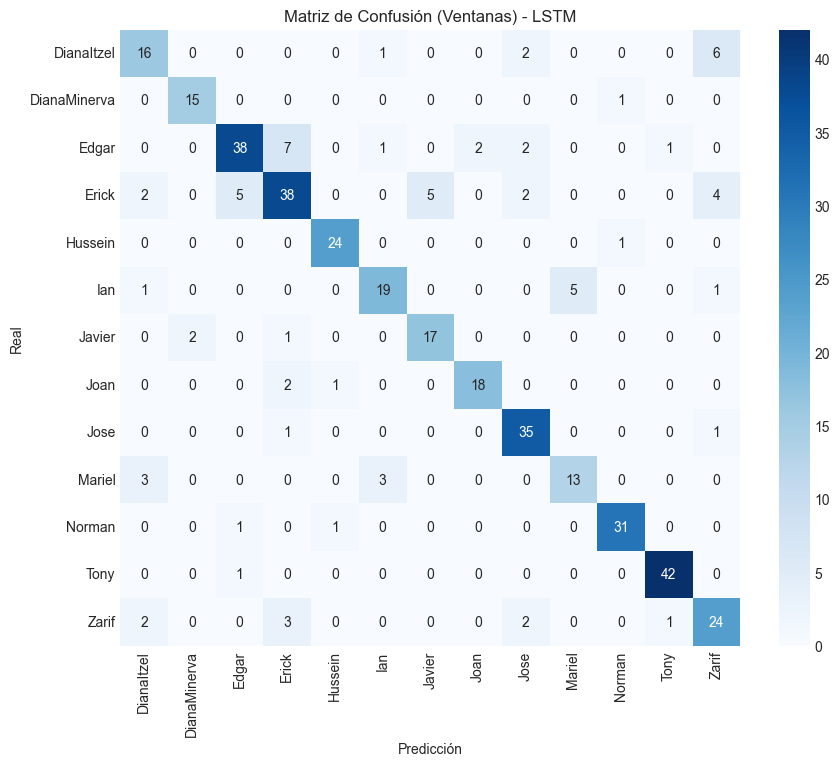


-------------------- NIVEL VIDEO (VOTACIÓN) --------------------
Videos Totales: 50
Videos Correctos: 46
Accuracy por Video: 92.00%


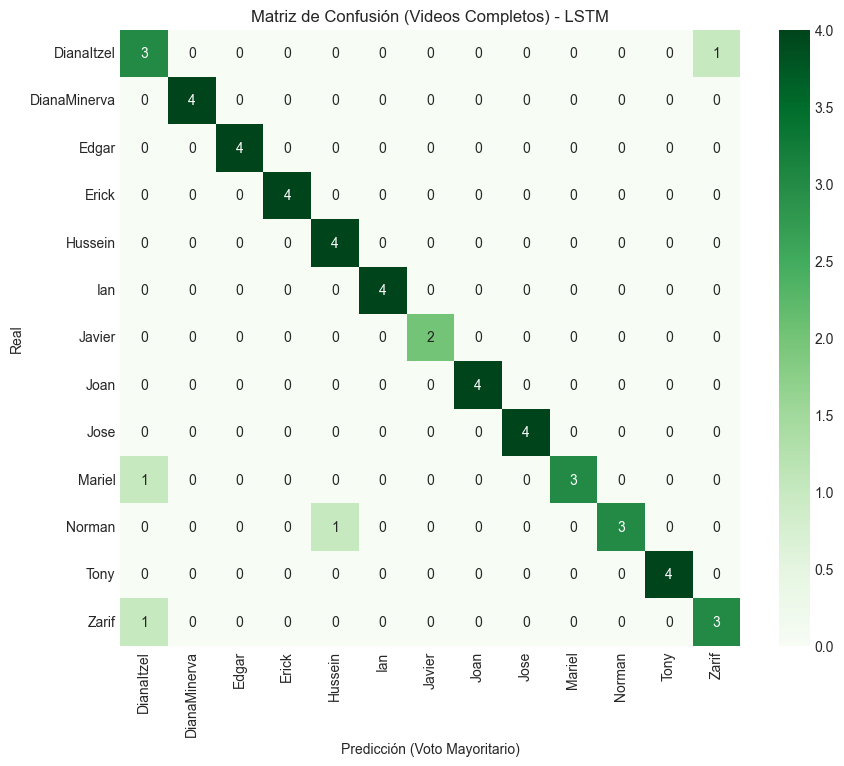


Reporte de Clasificación (Por Videos):
              precision    recall  f1-score   support

  DianaItzel       0.60      0.75      0.67         4
DianaMinerva       1.00      1.00      1.00         4
       Edgar       1.00      1.00      1.00         4
       Erick       1.00      1.00      1.00         4
     Hussein       0.80      1.00      0.89         4
         Ian       1.00      1.00      1.00         4
      Javier       1.00      1.00      1.00         2
        Joan       1.00      1.00      1.00         4
        Jose       1.00      1.00      1.00         4
      Mariel       1.00      0.75      0.86         4
      Norman       1.00      0.75      0.86         4
        Tony       1.00      1.00      1.00         4
       Zarif       0.75      0.75      0.75         4

    accuracy                           0.92        50
   macro avg       0.93      0.92      0.92        50
weighted avg       0.93      0.92      0.92        50


 EVALUANDO CNN-1D CON STRATIFIED GROUP

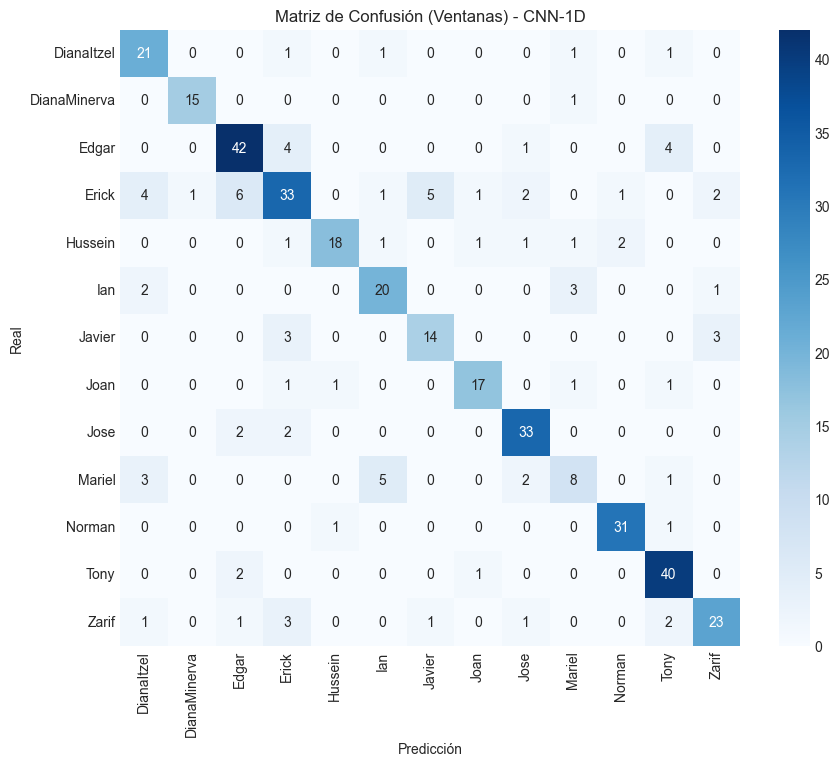


-------------------- NIVEL VIDEO (VOTACIÓN) --------------------
Videos Totales: 50
Videos Correctos: 46
Accuracy por Video: 92.00%


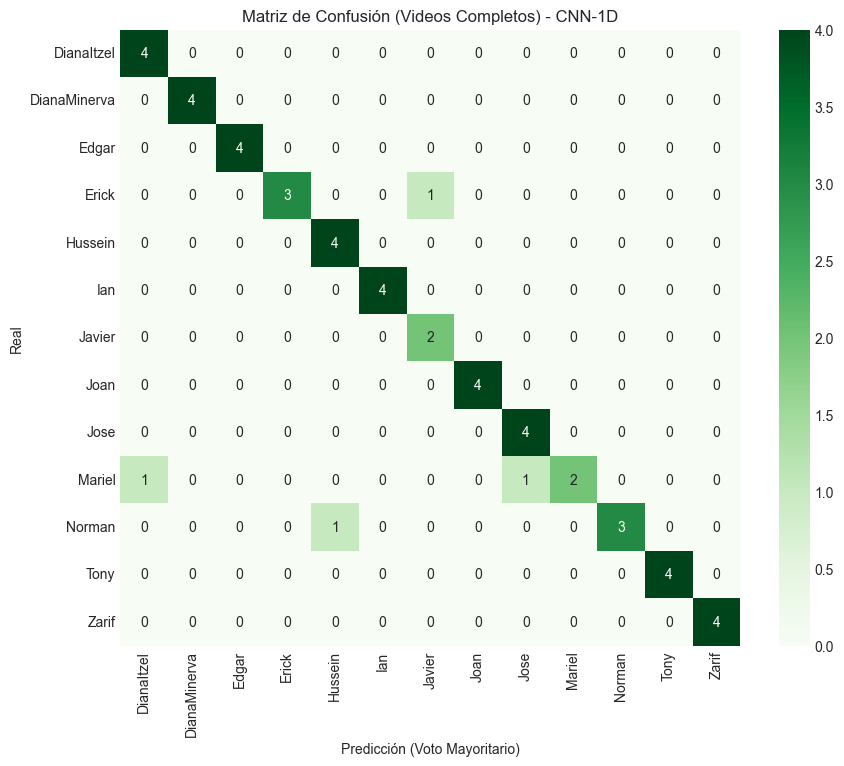


Reporte de Clasificación (Por Videos):
              precision    recall  f1-score   support

  DianaItzel       0.80      1.00      0.89         4
DianaMinerva       1.00      1.00      1.00         4
       Edgar       1.00      1.00      1.00         4
       Erick       1.00      0.75      0.86         4
     Hussein       0.80      1.00      0.89         4
         Ian       1.00      1.00      1.00         4
      Javier       0.67      1.00      0.80         2
        Joan       1.00      1.00      1.00         4
        Jose       0.80      1.00      0.89         4
      Mariel       1.00      0.50      0.67         4
      Norman       1.00      0.75      0.86         4
        Tony       1.00      1.00      1.00         4
       Zarif       1.00      1.00      1.00         4

    accuracy                           0.92        50
   macro avg       0.93      0.92      0.91        50
weighted avg       0.94      0.92      0.92        50


 EVALUANDO CNN-LSTM CON STRATIFIED GRO

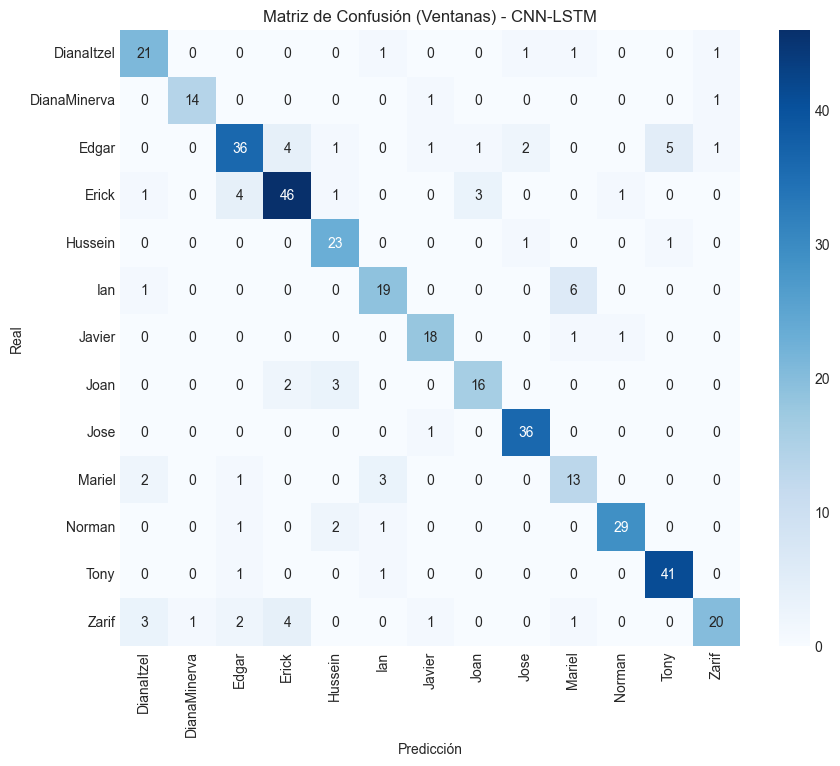


-------------------- NIVEL VIDEO (VOTACIÓN) --------------------
Videos Totales: 50
Videos Correctos: 48
Accuracy por Video: 96.00%


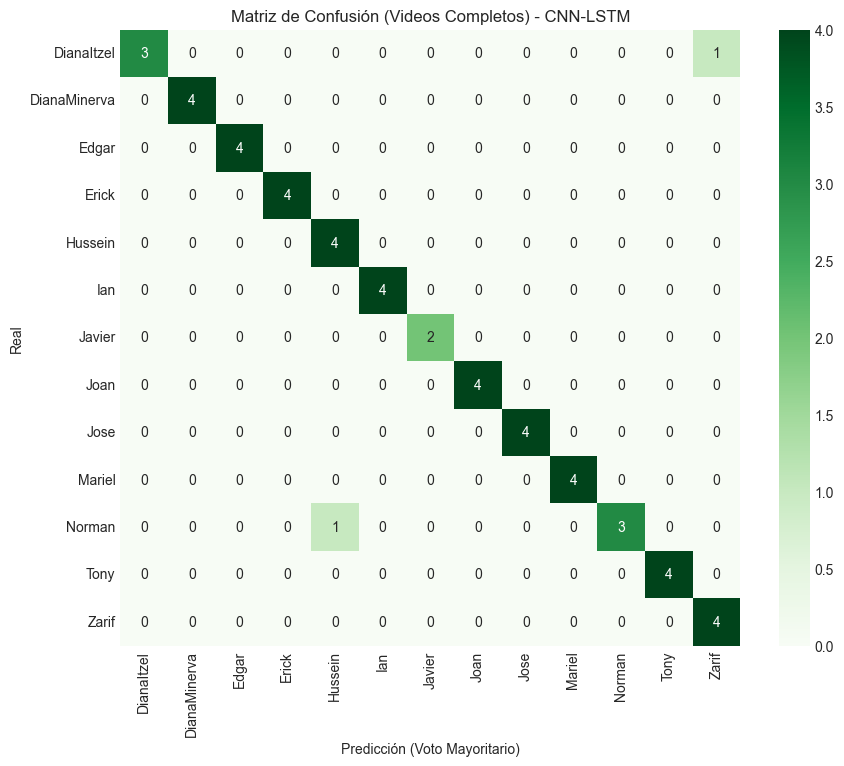


Reporte de Clasificación (Por Videos):
              precision    recall  f1-score   support

  DianaItzel       1.00      0.75      0.86         4
DianaMinerva       1.00      1.00      1.00         4
       Edgar       1.00      1.00      1.00         4
       Erick       1.00      1.00      1.00         4
     Hussein       0.80      1.00      0.89         4
         Ian       1.00      1.00      1.00         4
      Javier       1.00      1.00      1.00         2
        Joan       1.00      1.00      1.00         4
        Jose       1.00      1.00      1.00         4
      Mariel       1.00      1.00      1.00         4
      Norman       1.00      0.75      0.86         4
        Tony       1.00      1.00      1.00         4
       Zarif       0.80      1.00      0.89         4

    accuracy                           0.96        50
   macro avg       0.97      0.96      0.96        50
weighted avg       0.97      0.96      0.96        50


--- RESUMEN FINAL DE MODELOS ---
LSTM:

In [53]:
modelos_a_evaluar = {
    "LSTM": build_lstm,
    "CNN-1D": build_cnn1d,
    "CNN-LSTM": build_cnn_lstm
}

resultados_f1 = {}
resultados_acc_video = {}

for nombre, constructor in modelos_a_evaluar.items():
    f1, acc_video = evaluate_with_kfold(
        model_builder=constructor,
        X=X_norm,       
        y_int=y_int,    
        y_onehot=y_onehot, 
        encoder=encoder,  
        video_ids=video_ids_raw,
        n_classes=n_classes,
        name=nombre
    )
    resultados_f1[nombre] = f1
    resultados_acc_video[nombre] = acc_video

print("\n--- RESUMEN FINAL DE MODELOS ---")
for m, score in resultados_f1.items():
    print(f"{m}: F1-Score = {score:.4f}")

### Evaluación de Modelos